In [47]:
import pandas as pd
from math import cos, radians, sqrt
from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import warnings
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.decomposition import PCA
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.oneway import anova_oneway
import pingouin as pg
from matplotlib.ticker import StrMethodFormatter

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')

In [8]:
raw = "C:\\Users\\Taavi\\Desktop\\BPhil\\Raw data\\"
clean = "C:\\Users\\Taavi\\Desktop\\BPhil\\Clean data\\"
images = 'C:\\Users\\taavi\\Desktop\\BPHIL\\Images in defense ppt\\'

# Importing data

In [4]:
parcels = pd.read_csv(clean + 'blight.csv')

In [5]:
toMerge = pd.read_csv(clean + 'clean_parcels.csv')

parcels = parcels.merge(toMerge[['parcelID', 'geoID']], on = 'parcelID', how = 'left')
parcels['block_group'] = parcels['geoID'].astype(str).str[-4]
parcels = parcels[['parcelID', 'lat', 'lng', 'nbrhd', 'tract', 'block_group', 'blight', 'pc_blight', 'viols_sqrt', 'low_sqrt', 'high_sqrt']]

In [6]:
age = pd.read_csv(clean + 'age_ACS_data.csv')
empl = pd.read_csv(clean + 'employment_ACS_data.csv')
pov = pd.read_csv(clean + 'poverty_ACS_data.csv')
inc = pd.read_csv(clean + 'income_ACS_data.csv')
race = pd.read_csv(clean + 'race_ACS_data.csv')
sex = pd.read_csv(clean + 'sex_ACS_data.csv')
edu = pd.read_csv(clean + 'education_ACS_data.csv')

#### Race

Measuring the data

In [8]:
block_group_coords = parcels.groupby(['tract', 'block_group'])[['lat', 'lng']].median().reset_index()
block_group_coords['block_group'] = block_group_coords['block_group'].astype(int)

In [9]:
race = race.merge(block_group_coords, on = ['tract', 'block_group'], how = 'left').dropna().reset_index(drop = True)

In [ ]:
def calc_race_score(parcels, race, race_x):
    copy = parcels.copy()

    parcels_coords = np.radians(copy[['lat', 'lng']].values)
    race_coords = np.radians(race[['lat', 'lng']].values)

    earth_radius = 6_378_137 # chat-gpt said 6,371,000 but University of Southern Florida disagrees. I'm using USF
    race_tree = BallTree(race_coords, metric = 'haversine')

    distances = np.arange(50, 800, 50)
    distances_radians = distances / earth_radius
    weights = [(i + 1) / len(distances) for i, r in enumerate(distances)][::-1]

    # count violations in each distance bin
    for d_m, d_r in zip(distances, distances_radians):
        indices_within_radius = race_tree.query_radius(parcels_coords, r = d_r)
        counts = [len(idxs) for idxs in indices_within_radius]
        sums = [race.loc[idxs, f'{race_x}'].sum() for idxs in indices_within_radius]
        copy[f'{race_x}_count_{d_m}'] = counts
        copy[f'{race_x}_sum_{d_m}'] = sums

    for i, r in enumerate(distances[::-1]):
        if r != distances[0]:
            copy[f'{race_x}_count_{r}'] -= copy[f'{race_x}_count_{distances[::-1][i + 1]}']
            copy[f'{race_x}_sum_{r}'] -= copy[f'{race_x}_sum_{distances[::-1][i + 1]}']

    copy[f'{race_x}_count_decayed'] = (copy.iloc[:, -len(distances) * 2::2] * weights).sum(axis = 1)
    copy[f'{race_x}_sum_decayed'] = (copy.iloc[:, -len(distances) * 2::2] * weights).sum(axis = 1)

    copy[f'{race_x}_score'] = copy[f'{race_x}_sum_decayed'] / copy[f'{race_x}_count_decayed']

    return copy[f'{race_x}_score']

In [11]:
races = ['white', 'black', 'native', 'asian', 'islander', 'other', 'mixed']

In [ ]:
for r in races:
    parcels[f'{r}_score'] = calc_race_score(parcels, race, r)

In [ ]:
parcels.to_csv(clean + 'blight_and_race.csv', index = False)

In [7]:
parcels = pd.read_csv(clean + 'blight_and_race.csv')

In [22]:
parcels[[f'{r}_score' for r in races]].mean() * 100

white_score      63.15
black_score      25.00
native_score      0.13
asian_score       4.34
islander_score    0.10
other_score       1.23
mixed_score       4.73
dtype: float64

Analyzing the data

In [10]:
# for r in races:
#     plt.figure(figsize = (4, 2))
#     sns.kdeplot(race[r])
#     sns.kdeplot(parcels[f'{r}_score'], color = 'green')
#     plt.show()

These kde plots demonstrate the greater nuance captured through parcel-wise measurement than through aggregate measurement (in this case block group).

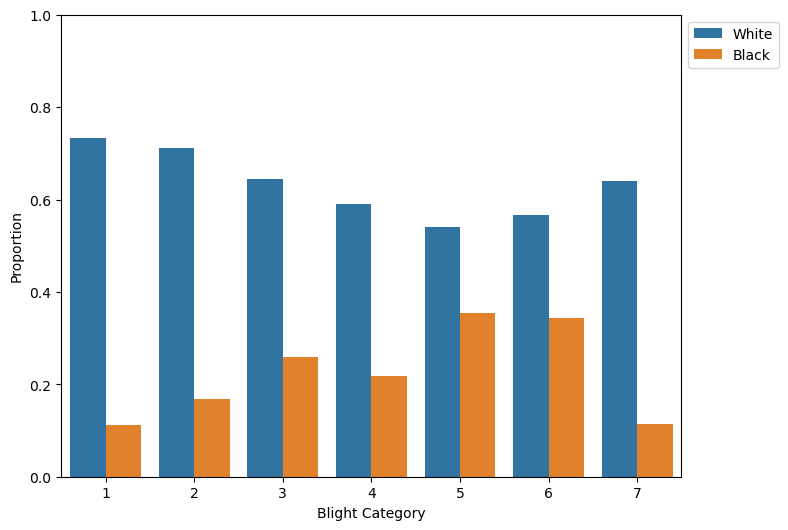

In [ ]:
toPlot = parcels.groupby('blight')[[f'{r}_score' for r in races]].mean().reset_index().melt(id_vars = 'blight', var_name = 'race', value_name = 'proportion')

toPlot = toPlot.query('race.isin(["white_score", "black_score"])')

toPlot['race'] = np.where(toPlot['race'] == 'white_score', 'White', np.where(toPlot['race'] == 'black_score', 'Black', toPlot['race']))

pop_means = {}
for r in races:
    pop_means[r] = parcels[r + '_score'].mean()

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'blight', y = 'proportion', hue = 'race')
#plt.axhline(pop_means['white'], color = 'blue')
plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.xlabel('Blight Category')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.savefig(images + 'race_by_blight.png', dpi = 300, bbox_inches = 'tight')
plt.show()

By appearances - and I'll have to verify this with tests - the white population is substantially lower in high-blight areas than in low-blight areas, and the exact opposite is true of the black population.

To test, I want to test each race's mean proportion, in each blight category, against that race's population mean proportion.

I also want to do ANOVA tests for each race's mean proportion across each blight category.

In [76]:
model = smf.ols(formula = 'black_score ~ C(blight)', data = parcels).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            black_score   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     2687.
Date:                Tue, 20 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:51:48   Log-Likelihood:                 128.44
No. Observations:              135928   AIC:                            -242.9
Df Residuals:                  135921   BIC:                            -174.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.1120      0.002     51.

In [59]:
model = smf.ols(formula = 'white_score ~ viols_sqrt + low_sqrt + high_sqrt', data = parcels).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            white_score   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     3478.
Date:                Mon, 19 Jan 2026   Prob (F-statistic):               0.00
Time:                        09:29:34   Log-Likelihood:                 2544.0
No. Observations:              135928   AIC:                            -5080.
Df Residuals:                  135924   BIC:                            -5041.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8229      0.002    400.018      0.0

In [ ]:
parcels[['pc_blight', 'viols_sqrt', 'low_sqrt', 'high_sqrt'] + [f'{r}_score' for r in races]].corr().iloc[4:, :4]

,pc_blight,viols_sqrt,low_sqrt,high_sqrt
white_score,-0.26,-0.24,-0.24,-0.21
black_score,0.29,0.31,0.25,0.18
native_score,0.28,0.29,0.23,0.19
asian_score,-0.02,-0.18,0.08,0.22
islander_score,0.05,-0.08,0.17,0.16
other_score,0.19,0.22,0.12,0.09
mixed_score,-0.17,-0.18,-0.14,-0.11


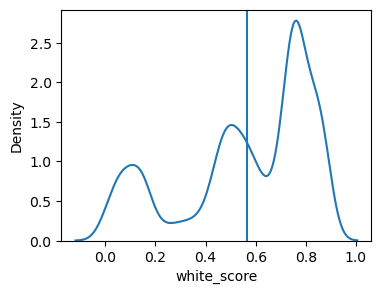

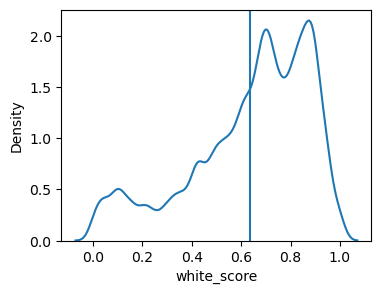

In [70]:
plt.figure(figsize = (4, 3))
sns.kdeplot(parcels.query('blight == 6')[f'white_score'].dropna())
plt.axvline(x = parcels.query('blight == 6')[f'white_score'].dropna().mean())
plt.show()
plt.figure(figsize = (4, 3))
sns.kdeplot(parcels.query('blight != 6')[f'white_score'].dropna())
plt.axvline(x = parcels.query('blight != 6')[f'white_score'].dropna().mean())
plt.show()

In [72]:
blight_vals = []
race_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    for r in races:
        sample = parcels.query('blight == @i')[f'{r}_score'].dropna()
        pop = parcels.query('blight != @i')[f'{r}_score'].dropna()

        t, p = stats.ttest_ind(sample, pop, equal_var = False)

        blight_vals.append(i)
        race_vals.append(r)
        t_vals.append(t)
        p_vals.append(p)
        samp1_mean_vals.append(sample.mean() * 100)
        samp2_mean_vals.append(pop.mean() * 100)
        samp1_n_vals.append(len(sample))
        samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight': blight_vals,
    'Race': race_vals,
    'Blight Mean': samp1_mean_vals,
    'Other Blight Mean': samp2_mean_vals,
    'Blight N': samp1_n_vals,
    'Other Blight N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [73]:
results.query('Race.isin(["white", "black"])')

,Blight,Race,Blight Mean,Other Blight Mean,Blight N,Other Blight N,t,p
0,1,white,73.40,62.13,12282,123646,57.98,0.00
1,1,black,11.20,26.37,12282,123646,-99.41,0.00
7,2,white,71.04,60.81,31005,104923,77.83,0.00
8,2,black,16.92,27.39,31005,104923,-80.43,0.00
14,3,white,64.43,62.71,34669,101259,11.23,0.00
15,3,black,26.00,24.66,34669,101259,8.62,0.00
21,4,white,59.04,63.53,11505,124423,-21.97,0.00
22,4,black,21.84,25.29,11505,124423,-13.75,0.00
28,5,white,54.11,65.94,32105,103823,-68.21,0.00
29,5,black,35.41,21.78,32105,103823,75.43,0.00


In [327]:
r_vals = []
f_vals = []
p_vals = []

for r in races:
    samples = [parcels.query('blight == @i')[f'{r}_score'].dropna() for i in parcels['blight'].sort_values().unique()]
    f, p = anova_oneway(samples, use_var = 'unequal')

    r_vals.append(r)
    f_vals.append(f)
    p_vals.append(p)

results_anova = pd.DataFrame({
    'Race': r_vals,
    'F-Statistic': f_vals,
    'P-Value': p_vals
})

In [328]:
results_anova

,Race,F-Statistic,P-Value
0,white,2080.75,0.00
1,black,3821.37,0.00
2,native,2726.89,0.00
3,asian,4517.84,0.00
4,islander,NaN,NaN
5,other,3717.25,0.00
6,mixed,2903.67,0.00


In [331]:
for r in races:
    df = parcels[['blight', f'{r}_score']].dropna()

    gh = pg.pairwise_gameshowell(
        data = df,
        dv = f'{r}_score',
        between = 'blight'
    )

    print(f'\nRace: {r}')
    print(gh[['A', 'B', 'mean(A)', 'mean(B)', 'diff', 'pval']])


Race: white
    A  B  mean(A)  mean(B)  diff  pval
0   1  2     0.73     0.71  0.02  0.00
1   1  3     0.73     0.64  0.09  0.00
2   1  4     0.73     0.59  0.14  0.00
3   1  5     0.73     0.54  0.19  0.00
4   1  6     0.73     0.57  0.17  0.00
5   1  7     0.73     0.64  0.09  0.00
6   2  3     0.71     0.64  0.07  0.00
7   2  4     0.71     0.59  0.12  0.00
8   2  5     0.71     0.54  0.17  0.00
9   2  6     0.71     0.57  0.14  0.00
10  2  7     0.71     0.64  0.07  0.00
11  3  4     0.64     0.59  0.05  0.00
12  3  5     0.64     0.54  0.10  0.00
13  3  6     0.64     0.57  0.08  0.00
14  3  7     0.64     0.64  0.00  0.50
15  4  5     0.59     0.54  0.05  0.00
16  4  6     0.59     0.57  0.02  0.00
17  4  7     0.59     0.64 -0.05  0.00
18  5  6     0.54     0.57 -0.03  0.00
19  5  7     0.54     0.64 -0.10  0.00
20  6  7     0.57     0.64 -0.07  0.00

Race: black
    A  B  mean(A)  mean(B)  diff  pval
0   1  2     0.11     0.17 -0.06  0.00
1   1  3     0.11     0.26 -0.15  0.00

#### Employment

Measuring the data

In [58]:
block_group_coords = parcels.groupby(['tract', 'block_group'])[['lat', 'lng']].median().reset_index()
block_group_coords['block_group'] = block_group_coords['block_group'].astype(int)

In [59]:
empl = empl.merge(block_group_coords, on = ['tract', 'block_group'], how = 'left').dropna().reset_index(drop = True)

In [26]:
empls = ['labor_force', 'employed', 'unemployed']

In [108]:
for e in empls:
    parcels[f'{e}_score'] = calc_race_score(parcels, empl, e)

In [127]:
parcels.to_csv(clean + 'blight_and_employment.csv', index = False)

In [37]:
parcels = pd.read_csv(clean + 'blight_and_employment.csv')

Analyzing the data

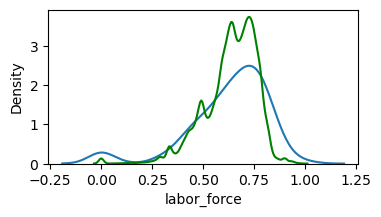

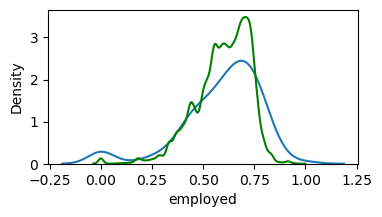

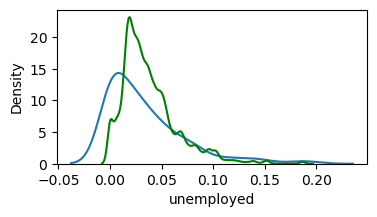

In [129]:
for e in empls:
    plt.figure(figsize = (4, 2))
    sns.kdeplot(empl[e])
    sns.kdeplot(parcels[f'{e}_score'], color = 'green')
    plt.show()

In [39]:
parcels['employed_over_lf_score'] = parcels['employed_score'] / parcels['labor_force_score']

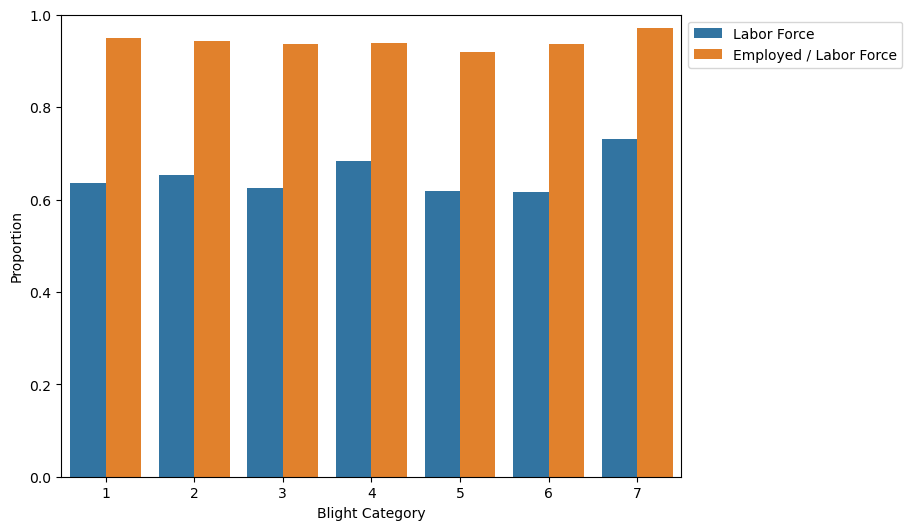

In [40]:
empls = ['labor_force', 'employed_over_lf']

toPlot = parcels.groupby('blight')[[f'{e}_score' for e in empls]].mean().reset_index().melt(id_vars = 'blight', var_name = 'employment_status', value_name = 'proportion')

toPlot['employment_status'] = np.where(toPlot['employment_status'] == 'labor_force_score', 'Labor Force', np.where(toPlot['employment_status'] == 'employed_over_lf_score', 'Employed / Labor Force', toPlot['employment_status']))

pop_means = {}
for e in empls:
    pop_means[e] = parcels[e + '_score'].mean()

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'blight', y = 'proportion', hue = 'employment_status')
# for e in empls:
#     plt.axhline(y = pop_means[e])
plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.xlabel('Blight Category')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.savefig(images + 'employment_by_blight.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [106]:
blight_vals = []
empl_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    for e in empls:
        sample = parcels.query('blight == @i')[f'{e}_score'].dropna()
        pop = parcels.query('blight != @i')[f'{e}_score'].dropna()

        t, p = stats.ttest_ind(sample, pop, equal_var = False)

        blight_vals.append(i)
        empl_vals.append(e)
        t_vals.append(t)
        p_vals.append(p)
        samp1_mean_vals.append(sample.mean() * 100)
        samp2_mean_vals.append(pop.mean() * 100)
        samp1_n_vals.append(len(sample))
        samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight': blight_vals,
    'Employment': empl_vals,
    'Blight Mean': samp1_mean_vals,
    'Other Blight Mean': samp2_mean_vals,
    'Blight N': samp1_n_vals,
    'Other Blight N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [107]:
results

,Blight,Employment,Blight Mean,Other Blight Mean,Blight N,Other Blight N,t,p
0,1,labor_force,63.57,63.65,12282,123646,-0.52,0.61
1,1,employed_over_lf,94.91,93.41,12175,123221,30.94,0.00
2,2,labor_force,65.34,63.14,31005,104923,30.30,0.00
3,2,employed_over_lf,94.31,93.32,30900,104496,31.64,0.00
4,3,labor_force,62.53,64.02,34669,101259,-18.60,0.00
5,3,employed_over_lf,93.59,93.53,34463,100933,1.91,0.06
6,4,labor_force,68.41,63.20,11505,124423,48.23,0.00
7,4,employed_over_lf,93.92,93.51,11505,123891,7.09,0.00
8,5,labor_force,61.74,64.23,32105,103823,-29.86,0.00
9,5,employed_over_lf,91.87,94.07,31991,103405,-64.97,0.00


In [63]:
parcels[['pc_blight', 'viols_sqrt', 'low_sqrt', 'high_sqrt'] + [f'{e}_score' for e in empls]].corr().iloc[4:, :4]

,pc_blight,viols_sqrt,low_sqrt,high_sqrt
labor_force_score,-0.04,-0.13,0.04,0.08
employed_score,-0.06,-0.16,0.03,0.07
unemployed_score,0.11,0.14,0.08,0.04


In [109]:
model = smf.ols(formula = 'employed_over_lf_score ~ C(blight)', data = parcels).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     employed_over_lf_score   R-squared:                       0.043
Model:                                OLS   Adj. R-squared:                  0.043
Method:                     Least Squares   F-statistic:                     1025.
Date:                    Tue, 20 Jan 2026   Prob (F-statistic):               0.00
Time:                            22:26:28   Log-Likelihood:             2.1123e+05
No. Observations:                  135396   AIC:                        -4.224e+05
Df Residuals:                      135389   BIC:                        -4.224e+05
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Inte

In [359]:
blight_vals = []
empl_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    for e in empls:
        sample = parcels.query('blight == @i')[f'{e}_score'].dropna()
        pop = parcels.query('blight != @i')[f'{e}_score'].dropna()

        t, p = stats.ttest_ind(sample, pop, equal_var = False)

        blight_vals.append(i)
        empl_vals.append(e)
        t_vals.append(t)
        p_vals.append(p)
        samp1_mean_vals.append(sample.mean())
        samp2_mean_vals.append(pop.mean())
        samp1_n_vals.append(len(sample))
        samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight Sample': blight_vals,
    'Employment Status': empl_vals,
    'Sample Mean': samp1_mean_vals,
    'Population Mean': samp2_mean_vals,
    'Sample N': samp1_n_vals,
    'Population N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [360]:
results

,Blight Sample,Employment Status,Sample Mean,Population Mean,Sample N,Population N,t,p
0,1,labor_force,0.64,0.64,12282,123646,-0.52,0.61
1,1,employed,0.60,0.60,12282,123646,4.89,0.00
2,1,unemployed,0.03,0.04,12282,123646,-27.59,0.00
3,2,labor_force,0.65,0.63,31005,104923,30.30,0.00
4,2,employed,0.62,0.59,31005,104923,34.43,0.00
5,2,unemployed,0.03,0.04,31005,104923,-25.25,0.00
6,3,labor_force,0.63,0.64,34669,101259,-18.60,0.00
7,3,employed,0.59,0.60,34669,101259,-16.19,0.00
8,3,unemployed,0.04,0.04,34669,101259,-10.17,0.00
9,4,labor_force,0.68,0.63,11505,124423,48.23,0.00


In [252]:
parcels[['blight', 'pc_blight', 'viols_sqrt', 'low_sqrt', 'high_sqrt']].assign(
    labor_force_score_sqrt = (parcels['labor_force_score']),
    employed_score_sqrt = (parcels['employed_score']),
    unemployed_score_sqrt = (parcels['unemployed_score'])
).corr().iloc[:5, 5:]

,labor_force_score_sqrt,employed_score_sqrt,unemployed_score_sqrt
blight,-0.04,-0.06,0.12
pc_blight,-0.04,-0.06,0.11
viols_sqrt,-0.13,-0.16,0.14
low_sqrt,0.04,0.03,0.08
high_sqrt,0.08,0.07,0.04


#### Sex

Measuring the data

In [ ]:
block_group_coords = parcels.groupby(['tract', 'block_group'])[['lat', 'lng']].median().reset_index()
block_group_coords['block_group'] = block_group_coords['block_group'].astype(int)

In [137]:
sex = sex.merge(block_group_coords, on = ['tract', 'block_group'], how = 'left').dropna().reset_index(drop = True)

In [138]:
sexes = ['male', 'female']

In [139]:
for s in sexes:
    parcels[f'{s}_score'] = calc_race_score(parcels, sex, s)

In [143]:
parcels.to_csv(clean + 'blight_and_sex.csv', index = False)

In [355]:
parcels = pd.read_csv(clean + 'blight_and_sex.csv')

Analyzing the data

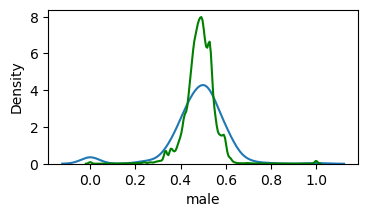

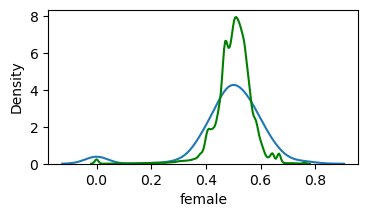

In [144]:
for s in sexes:
    plt.figure(figsize = (4, 2))
    sns.kdeplot(sex[s])
    sns.kdeplot(parcels[f'{s}_score'], color = 'green')
    plt.show()

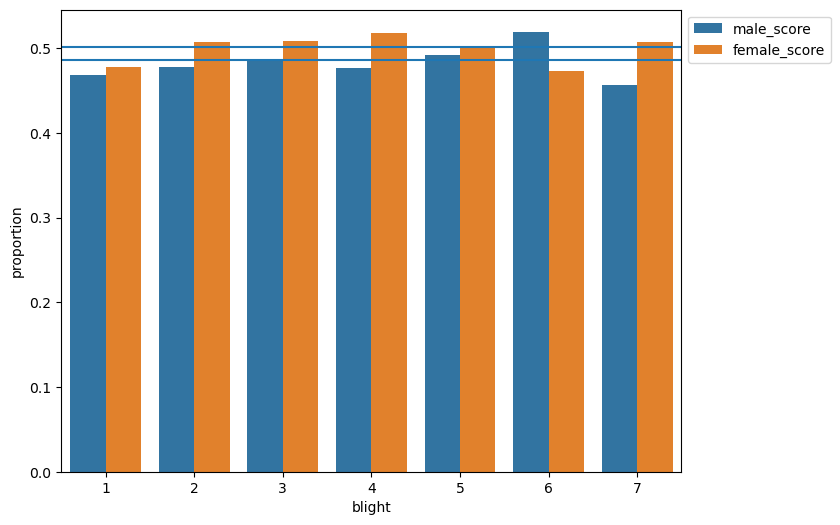

In [145]:
toPlot = parcels.groupby('blight')[[f'{s}_score' for s in sexes]].mean().reset_index().melt(id_vars = 'blight', var_name = 'sex', value_name = 'proportion')

pop_means = {}
for s in sexes:
    pop_means[s] = parcels[s + '_score'].mean()

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'blight', y = 'proportion', hue = 'sex')
for s in sexes:
    plt.axhline(y = pop_means[s])
plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.show()

In [289]:
model = smf.ols(formula = 'male_score ~ C(blight)', data = parcels).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             male_score   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     866.6
Date:                Sun, 04 Jan 2026   Prob (F-statistic):               0.00
Time:                        04:06:47   Log-Likelihood:             1.7300e+05
No. Observations:              135928   AIC:                        -3.460e+05
Df Residuals:                  135921   BIC:                        -3.459e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4680      0.001    765.

In [356]:
blight_vals = []
sex_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    for s in sexes:
        sample = parcels.query('blight == @i')[f'{s}_score'].dropna()
        pop = parcels.query('blight != @i')[f'{s}_score'].dropna()

        t, p = stats.ttest_ind(sample, pop, equal_var = False)

        blight_vals.append(i)
        sex_vals.append(s)
        t_vals.append(t)
        p_vals.append(p)
        samp1_mean_vals.append(sample.mean())
        samp2_mean_vals.append(pop.mean())
        samp1_n_vals.append(len(sample))
        samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight Sample': blight_vals,
    'Sex': sex_vals,
    'Sample Mean': samp1_mean_vals,
    'Population Mean': samp2_mean_vals,
    'Sample N': samp1_n_vals,
    'Population N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [357]:
results

,Blight Sample,Sex,Sample Mean,Population Mean,Sample N,Population N,t,p
0,1,male,0.47,0.49,12282,123646,-22.73,0.00
1,1,female,0.48,0.50,12282,123646,-29.08,0.00
2,2,male,0.48,0.49,31005,104923,-23.98,0.00
3,2,female,0.51,0.50,31005,104923,17.91,0.00
4,3,male,0.49,0.49,34669,101259,-1.65,0.10
5,3,female,0.51,0.50,34669,101259,22.77,0.00
6,4,male,0.48,0.49,11505,124423,-20.48,0.00
7,4,female,0.52,0.50,11505,124423,35.75,0.00
8,5,male,0.49,0.48,32105,103823,20.85,0.00
9,5,female,0.50,0.50,32105,103823,-1.22,0.22


#### Education

Measuring the data

In [336]:
block_group_coords = parcels.groupby(['tract', 'block_group'])[['lat', 'lng']].median().reset_index()
block_group_coords['block_group'] = block_group_coords['block_group'].astype(int)

In [337]:
edu = edu.merge(block_group_coords, on = ['tract', 'block_group'], how = 'left').dropna().reset_index(drop = True)

In [338]:
edus = ['high_school', 'bachelors', 'masters', 'professional', 'doctorate']

In [339]:
edu['none'] = 1 - edu[edus].sum(axis = 1)

In [32]:
edus = ['none', 'high_school', 'bachelors', 'masters', 'professional', 'doctorate']

In [342]:
for e in edus:
    parcels[f'{e}_score'] = calc_race_score(parcels, edu, e)

In [362]:
parcels.to_csv(clean + 'blight_and_education.csv', index = False)

In [41]:
parcels = pd.read_csv(clean + 'blight_and_education.csv')

Analyzing the data

In [30]:
# for e in edus:
#     plt.figure(figsize = (4, 2))
#     sns.kdeplot(edu[e])
#     sns.kdeplot(parcels[f'{e}_score'], color = 'green')#, bw_adjust = 0.1)
#     plt.show()

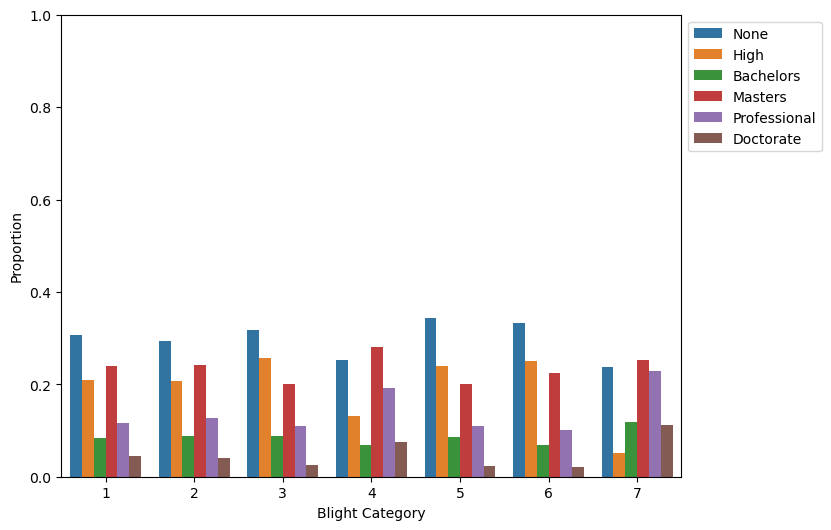

In [43]:
toPlot = parcels.groupby('blight')[[f'{e}_score' for e in edus]].mean().reset_index().melt(id_vars = 'blight', var_name = 'education', value_name = 'proportion')

toPlot['education'] = toPlot['education'].str.split('_').str[0].str.title()

pop_means = {}
for e in edus:
    pop_means[e] = parcels[e + '_score'].mean()

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'blight', y = 'proportion', hue = 'education')
# for e in edus:
#     plt.axhline(y = pop_means[e])
plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.ylim(0, 1)
plt.xlabel('Blight Category')
plt.ylabel('Proportion')
plt.savefig(images + 'education_by_blight.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [123]:
blight_vals = []
edu_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    for e in edus:
        sample = parcels.query('blight == @i')[f'{e}_score'].dropna()
        pop = parcels.query('blight != @i')[f'{e}_score'].dropna()

        t, p = stats.ttest_ind(sample, pop, equal_var = False)

        blight_vals.append(i)
        edu_vals.append(e)
        t_vals.append(t)
        p_vals.append(p)
        samp1_mean_vals.append(sample.mean() * 100)
        samp2_mean_vals.append(pop.mean() * 100)
        samp1_n_vals.append(len(sample))
        samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight Sample': blight_vals,
    'Education': edu_vals,
    'Sample Mean': samp1_mean_vals,
    'Population Mean': samp2_mean_vals,
    'Sample N': samp1_n_vals,
    'Population N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [124]:
results.sort_values(by = ['Education', 'Blight Sample'])

,Blight Sample,Education,Sample Mean,Population Mean,Sample N,Population N,t,p
2,1,bachelors,8.46,8.46,12282,123646,0.07,0.94
8,2,bachelors,8.91,8.32,31005,104923,16.74,0.00
14,3,bachelors,8.85,8.32,34669,101259,17.07,0.00
20,4,bachelors,6.93,8.60,11505,124423,-24.67,0.00
26,5,bachelors,8.53,8.44,32105,103823,3.40,0.00
32,6,bachelors,6.91,8.61,12380,123548,-60.25,0.00
38,7,bachelors,11.77,8.41,1982,133946,12.21,0.00
5,1,doctorate,4.40,3.42,12282,123646,21.64,0.00
11,2,doctorate,4.03,3.36,31005,104923,23.60,0.00
17,3,doctorate,2.60,3.82,34669,101259,-59.21,0.00


In [321]:
test = parcels.copy()
for i in edus:
    test[f'{i}_score'] = np.sqrt(test[f'{i}_score'])
    
test[['viols_sqrt', 'low_sqrt', 'high_sqrt', 'pc_blight', 'blight', 'high_school_score', 'bachelors_score', 'masters_score', 'professional_score', 'doctorate_score']].corr().iloc[-5:, :-5]

,viols_sqrt,low_sqrt,high_sqrt,pc_blight,blight
high_school_score,0.24,-0.01,-0.13,0.10,0.04
bachelors_score,0.02,-0.05,-0.08,-0.02,-0.03
masters_score,-0.15,-0.00,0.07,-0.07,-0.06
professional_score,-0.16,0.05,0.15,-0.04,0.01
doctorate_score,-0.28,0.02,0.12,-0.12,-0.07


In [139]:
model = smf.ols(formula = 'doctorate_score ~ C(blight)', data = parcels).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        doctorate_score   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     5379.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        10:56:39   Log-Likelihood:             2.5979e+05
No. Observations:              135928   AIC:                        -5.196e+05
Df Residuals:                  135921   BIC:                        -5.195e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0440      0.000    136.

In [162]:
parcels.query('blight == 6').groupby('nbrhd')['none_score'].mean().sort_values()

nbrhd
South Side Flats    0.17
South Side Slopes   0.28
Arlington Heights   0.29
Mount Washington    0.35
Homewood West       0.35
Homewood North      0.36
Homewood South      0.36
South Oakland       0.37
Knoxville           0.39
Beltzhoover         0.40
Allentown           0.46
Mt. Oliver          0.46
Central Oakland     0.53
Name: none_score, dtype: float64

#### Poverty

In [296]:
block_group_coords = parcels.groupby(['tract', 'block_group'])[['lat', 'lng']].median().reset_index()
block_group_coords['block_group'] = block_group_coords['block_group'].astype(int)

In [ ]:
pov = pov.merge(block_group_coords, on = ['tract'], how = 'left').dropna().reset_index(drop = True)
pov = pov.drop(columns = 'block_group')

In [301]:
parcels[f'impoverished_score'] = calc_race_score(parcels, pov, 'impoverished')

In [308]:
parcels.to_csv(clean + 'blight_and_poverty.csv', index = False)

In [44]:
parcels = pd.read_csv(clean + 'blight_and_poverty.csv')

Analyzing the data

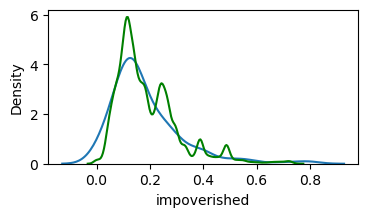

In [310]:
plt.figure(figsize = (4, 2))
sns.kdeplot(pov['impoverished'])
sns.kdeplot(parcels['impoverished_score'], color = 'green')
plt.show()

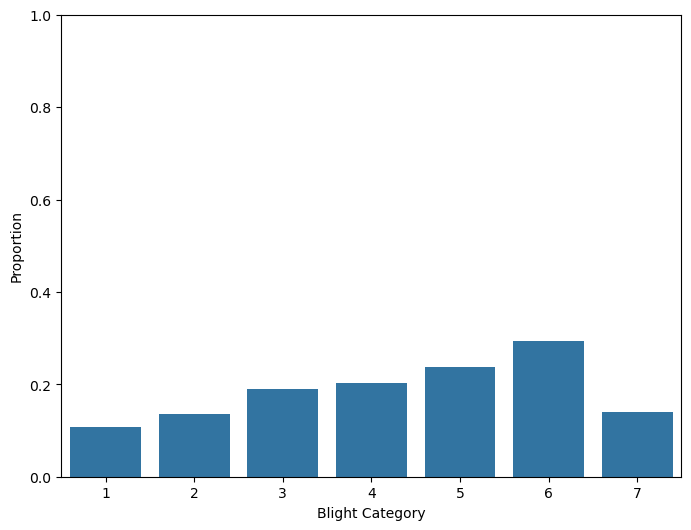

In [45]:
toPlot = parcels.groupby('blight')['impoverished_score'].mean().reset_index()

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'blight', y = 'impoverished_score')
pop_mean = parcels['impoverished_score'].mean()
# plt.axhline(y = pop_mean)
plt.ylim(0, 1)
plt.xlabel('Blight Category')
plt.ylabel('Proportion')
plt.savefig(images + 'poverty_by_blight.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [147]:
blight_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    sample = parcels.query('blight == @i')['impoverished_score'].dropna()
    pop = parcels.query('blight != @i')['impoverished_score'].dropna()

    t, p = stats.ttest_ind(sample, pop, equal_var = False)

    blight_vals.append(i)
    t_vals.append(t)
    p_vals.append(p)
    samp1_mean_vals.append(sample.mean() * 100)
    samp2_mean_vals.append(pop.mean() * 100)
    samp1_n_vals.append(len(sample))
    samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight Sample': blight_vals,
    'Sample Mean': samp1_mean_vals,
    'Population Mean': samp2_mean_vals,
    'Sample N': samp1_n_vals,
    'Population N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [148]:
results

,Blight Sample,Sample Mean,Population Mean,Sample N,Population N,t,p
0,1,10.73,19.95,12762,125332,-124.13,0.00
1,2,13.47,20.76,31482,106612,-125.19,0.00
2,3,19.10,19.10,35182,102912,-0.03,0.97
3,4,20.21,18.99,11658,126436,11.59,0.00
4,5,23.85,17.63,32648,105446,79.32,0.00
5,6,29.27,18.10,12380,125714,88.10,0.00
6,7,14.01,19.17,1982,136112,-102.77,0.00


In [146]:
model = smf.ols(formula = 'impoverished_score ~ C(blight)', data = parcels).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     impoverished_score   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     5879.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        13:45:28   Log-Likelihood:             1.1382e+05
No. Observations:              138094   AIC:                        -2.276e+05
Df Residuals:                  138087   BIC:                        -2.276e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.1073      0.001    114.

In [313]:
parcels[['viols_sqrt', 'low_sqrt', 'high_sqrt', 'pc_blight', 'blight', 'impoverished_score']].corr().iloc[-1:, :-1]

,viols_sqrt,low_sqrt,high_sqrt,pc_blight,blight
impoverished_score,0.47,0.33,0.29,0.44,0.41


In [324]:
test = parcels.copy()
test['impoverished_score'] = np.sqrt(test['impoverished_score'])
test[['viols_sqrt', 'low_sqrt', 'high_sqrt', 'pc_blight', 'blight', 'impoverished_score']].corr().iloc[-1:, :-1]

,viols_sqrt,low_sqrt,high_sqrt,pc_blight,blight
impoverished_score,0.50,0.37,0.33,0.47,0.44


#### Income

Measuring the data

In [146]:
block_group_coords = parcels.groupby(['tract', 'block_group'])[['lat', 'lng']].median().reset_index()
block_group_coords['block_group'] = block_group_coords['block_group'].astype(int)

In [147]:
inc = inc.merge(block_group_coords, on = ['tract', 'block_group'], how = 'left').dropna().reset_index(drop = True)

In [149]:
parcels[f'median_income'] = calc_race_score(parcels, inc, 'median_household_income')

In [153]:
parcels.to_csv(clean + 'blight_and_income.csv', index = False)

In [46]:
parcels = pd.read_csv(clean + 'blight_and_income.csv')

Analyzing the data

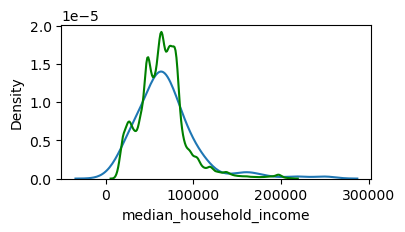

In [154]:
plt.figure(figsize = (4, 2))
sns.kdeplot(inc['median_household_income'])
sns.kdeplot(parcels['median_income'], color = 'green')
plt.show()

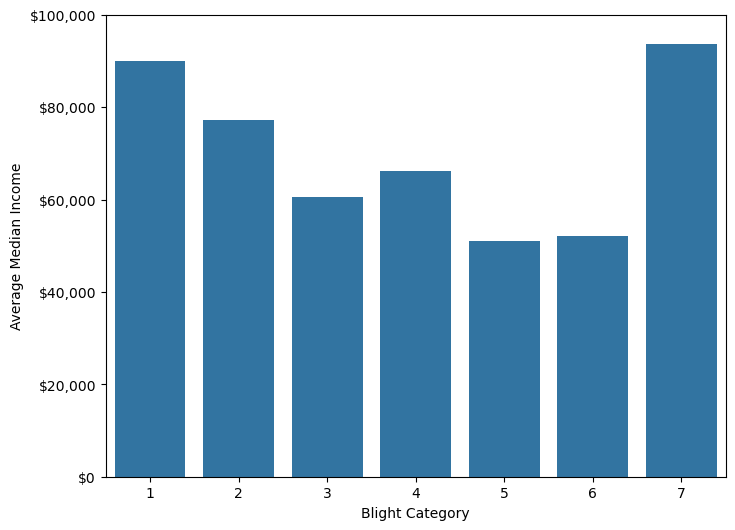

In [51]:
toPlot = parcels.groupby('blight')['median_income'].mean().reset_index()

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'blight', y = 'median_income')
pop_mean = parcels['median_income'].mean()
# plt.axhline(y = pop_mean)
plt.xlabel('Blight Category')
plt.ylabel('Average Median Income')
plt.ylim(0, 100_000)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.savefig(images + 'income_by_blight.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [157]:
blight_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    sample = parcels.query('blight == @i')['median_income'].dropna()
    pop = parcels.query('blight != @i')['median_income'].dropna()

    t, p = stats.ttest_ind(sample, pop, equal_var = False)

    blight_vals.append(i)
    t_vals.append(t)
    p_vals.append(p)
    samp1_mean_vals.append(sample.mean())
    samp2_mean_vals.append(pop.mean())
    samp1_n_vals.append(len(sample))
    samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight Sample': blight_vals,
    'Sample Mean': samp1_mean_vals,
    'Population Mean': samp2_mean_vals,
    'Sample N': samp1_n_vals,
    'Population N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [158]:
results

,Blight Sample,Sample Mean,Population Mean,Sample N,Population N,t,p
0,1,89883.98,62456.42,11658,121519,80.74,0.00
1,2,77279.82,61141.99,30661,102516,85.61,0.00
2,3,60439.13,66322.73,33169,100008,-40.29,0.00
3,4,66152.20,64734.94,11504,121673,5.58,0.00
4,5,51044.39,69194.34,31823,101354,-130.62,0.00
5,6,52058.86,66169.03,12380,120797,-73.96,0.00
6,7,93627.86,64422.72,1982,131195,46.50,0.00


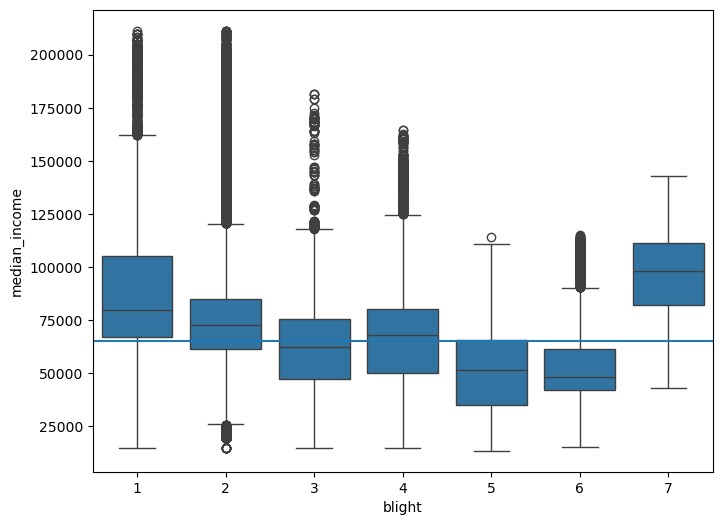

In [170]:
plt.figure(figsize = (8, 6))
sns.boxplot(parcels, x = 'blight', y = 'median_income')
pop_mean= parcels['median_income'].mean()
plt.axhline(y = pop_mean)
plt.show()

In [159]:
model = smf.ols(formula = 'median_income ~ C(blight)', data = parcels).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          median_income   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     6162.
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:22:02   Log-Likelihood:            -1.5357e+06
No. Observations:              133177   AIC:                         3.071e+06
Df Residuals:                  133170   BIC:                         3.071e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       8.988e+04    228.176    393.

In [353]:
blight_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    sample = parcels.query('blight == @i')['median_income'].dropna()
    pop = parcels.query('blight != @i')['median_income'].dropna()

    t, p = stats.ttest_ind(sample, pop, equal_var = False)

    blight_vals.append(i)
    t_vals.append(t)
    p_vals.append(p)
    samp1_mean_vals.append(sample.mean())
    samp2_mean_vals.append(pop.mean())
    samp1_n_vals.append(len(sample))
    samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight Sample': blight_vals,
    'Sample Mean': samp1_mean_vals,
    'Population Mean': samp2_mean_vals,
    'Sample N': samp1_n_vals,
    'Population N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [354]:
results

,Blight Sample,Sample Mean,Population Mean,Sample N,Population N,t,p
0,1,89883.98,62456.42,11658,121519,80.74,0.00
1,2,77279.82,61141.99,30661,102516,85.61,0.00
2,3,60439.13,66322.73,33169,100008,-40.29,0.00
3,4,66152.20,64734.94,11504,121673,5.58,0.00
4,5,51044.39,69194.34,31823,101354,-130.62,0.00
5,6,52058.86,66169.03,12380,120797,-73.96,0.00
6,7,93627.86,64422.72,1982,131195,46.50,0.00


#### Age

Cleaning the data to calculate 'mean_age'

In [114]:
age_cols = age.iloc[:, 3:].columns
ranges = []
for col in age_cols:
    if col == '-5':
        ranges.append([i for i in range(0, 5)])
    elif col == '85+':
        ranges.append([85])
    elif len(col.split('_')) > 1:
        first = int(col.split('_')[0])
        last = int(col.split('_')[1])
        ranges.append([i for i in range(first, last + 1)])
    else:
        ranges.append([int(col)])

full = pd.DataFrame()
for col, range_ in zip(age_cols, ranges):
    val = age[col] / len(range_)
    sub = pd.DataFrame()
    for i in range_:
        sub = pd.concat([sub, i * val], axis = 1)
    vals = np.sum(sub, axis = 1)
    full = pd.concat([full, vals], axis = 1)
mean_age = full.sum(axis = 1)

In [115]:
age['mean_age'] = mean_age

Calculating mean_age for ages 18+ (because under 18 is not adult)

In [116]:
age2 = age.drop(columns = 'mean_age').copy()
age2 = age2.drop(columns = ['-5', '5_9', '10_14', '15_17'])

In [117]:
age_cols = age2.iloc[:, 3:].columns

row_sums = age2[age_cols].sum(axis = 1)

for col in age_cols:
    age2[col] = age2[col] / row_sums

age2 = age2.fillna(0)

In [118]:
ranges = []
for col in age_cols:
    if col == '-5':
        ranges.append([i for i in range(0, 5)])
    elif col == '85+':
        ranges.append([85])
    elif len(col.split('_')) > 1:
        first = int(col.split('_')[0])
        last = int(col.split('_')[1])
        ranges.append([i for i in range(first, last + 1)])
    else:
        ranges.append([int(col)])

full = pd.DataFrame()
for col, range_ in zip(age_cols, ranges):
    val = age2[col] / len(range_)
    sub = pd.DataFrame()
    for i in range_:
        sub = pd.concat([sub, i * val], axis = 1)
    vals = np.sum(sub, axis = 1)
    full = pd.concat([full, vals], axis = 1)
mean_age2 = full.sum(axis = 1)

In [119]:
age2['mean_age'] = mean_age2

In [120]:
age['mean_age'].describe()

count   281.00
mean     38.15
std      10.40
min       0.00
25%      34.41
50%      39.00
75%      43.10
max      63.97
Name: mean_age, dtype: float64

In [121]:
age2['mean_age'].describe()

count   281.00
mean     43.06
std      11.37
min       0.00
25%      40.01
50%      45.27
75%      49.44
max      65.44
Name: mean_age, dtype: float64

Measuring the data

In [127]:
block_group_coords = parcels.groupby(['tract', 'block_group'])[['lat', 'lng']].median().reset_index()
block_group_coords['block_group'] = block_group_coords['block_group'].astype(int)

In [128]:
age = age.merge(block_group_coords, on = ['tract', 'block_group'], how = 'left').dropna().reset_index(drop = True)
age2 = age2.merge(block_group_coords, on = ['tract', 'block_group'], how = 'left').dropna().reset_index(drop = True)

In [131]:
parcels[f'mean_age'] = calc_race_score(parcels, age, 'mean_age')
parcels[f'mean_age2'] = calc_race_score(parcels, age2, 'mean_age')

In [263]:
parcels.to_csv(clean + 'blight_and_age.csv', index = False)

In [254]:
parcels = pd.read_csv(clean + 'blight_and_age.csv')

Analyzing the data

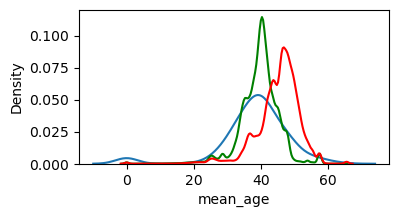

In [137]:
plt.figure(figsize = (4, 2))
sns.kdeplot(age['mean_age'])
sns.kdeplot(parcels['mean_age'], color = 'green')
sns.kdeplot(parcels['mean_age2'], color = 'red')
plt.show()

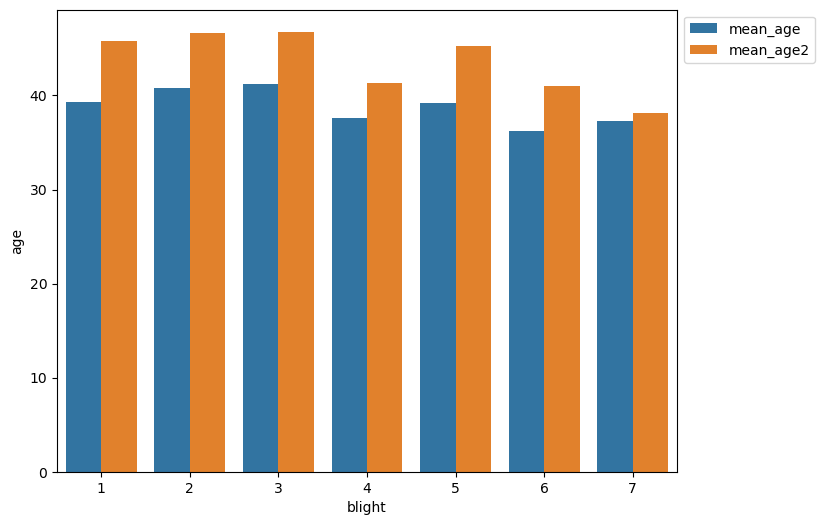

In [146]:
toPlot = parcels.groupby('blight')[['mean_age', 'mean_age2']].mean().reset_index().melt(id_vars = 'blight', var_name = 'method', value_name = 'age')

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'blight', y = 'age', hue = 'method')
# pop_mean = parcels['mean_age'].mean()
# plt.axhline(y = pop_mean)
plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.show()

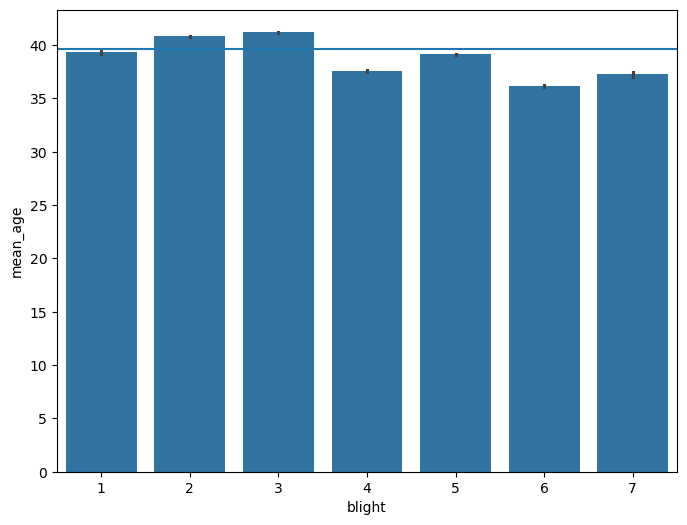

In [ ]:
plt.figure(figsize = (8, 6))
sns.barplot(parcels, x = 'blight', y = 'mean_age', errorbar = 'ci')
pop_mean = parcels['mean_age'].mean()
plt.axhline(y = pop_mean)
plt.show()

In [147]:
model = smf.ols(formula = 'mean_age2 ~ C(blight)', data = parcels).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              mean_age2   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     2990.
Date:                Fri, 09 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:39:15   Log-Likelihood:            -4.3577e+05
No. Observations:              135928   AIC:                         8.716e+05
Df Residuals:                  135921   BIC:                         8.716e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         45.7390      0.054    848.

In [348]:
blight_vals = []
t_vals = []
p_vals = []
samp1_mean_vals = []
samp2_mean_vals = []
samp1_n_vals = []
samp2_n_vals = []

for i in parcels['blight'].sort_values().unique():
    sample = parcels.query('blight == @i')['mean_age'].dropna()
    pop = parcels.query('blight != @i')['mean_age'].dropna()

    t, p = stats.ttest_ind(sample, pop, equal_var = False)

    blight_vals.append(i)
    t_vals.append(t)
    p_vals.append(p)
    samp1_mean_vals.append(sample.mean())
    samp2_mean_vals.append(pop.mean())
    samp1_n_vals.append(len(sample))
    samp2_n_vals.append(len(pop))

results = pd.DataFrame({
    'Blight Sample': blight_vals,
    'Sample Mean': samp1_mean_vals,
    'Population Mean': samp2_mean_vals,
    'Sample N': samp1_n_vals,
    'Population N': samp2_n_vals,
    't': t_vals,
    'p': p_vals
})

In [349]:
results

,Blight Sample,Sample Mean,Population Mean,Sample N,Population N,t,p
0,1,39.34,39.67,12282,123646,-4.28,0.00
1,2,40.81,39.30,31005,104923,43.58,0.00
2,3,41.20,39.11,34669,101259,63.37,0.00
3,4,37.59,39.83,11505,124423,-54.64,0.00
4,5,39.15,39.79,32105,103823,-19.28,0.00
5,6,36.20,39.99,12380,123548,-76.94,0.00
6,7,37.27,39.68,1982,133946,-21.48,0.00


Binning age data into -18, 18-22, 23-29, 30-66, 67+

Child, undergrad, post grad/young professional, settled, retired

In [256]:
age3 = age.drop(columns = 'mean_age').copy()

In [257]:
age3['22'] = age3['22_24'] * (1/3)
age3['23_24'] = age3['22_24'] * (2/3)

In [258]:
sub_18 = ['-5', '5_9', '10_14', '15_17']
undergrad = ['18_19', '20', '21', '22']
postgrad = ['23_24', '25_29']
settled = ['30_34', '35_39', '40_44', '45_49', '50_54', '55_59', '60_61', '62_64', '65_66']
retired = ['67_69', '70_74', '75_79', '80_84', '85+']

buckets = {
    'child': sub_18,
    'undergrad': undergrad,
    'postgrad': postgrad,
    'settled': settled,
    'retired': retired
}

for bucket in buckets:
    age3[bucket] = age3[buckets[bucket]].sum(axis = 1)

In [260]:
for b in buckets:
    parcels[f'{b}_score'] = calc_race_score(parcels, age3, b)

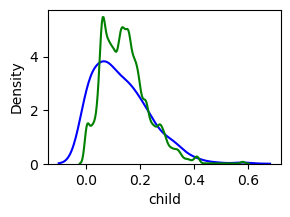

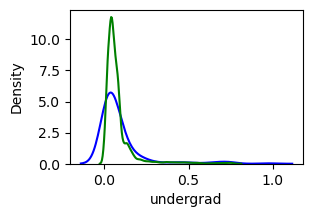

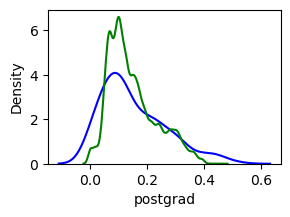

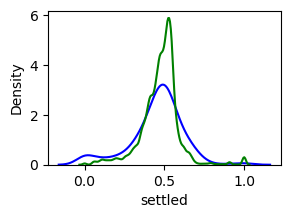

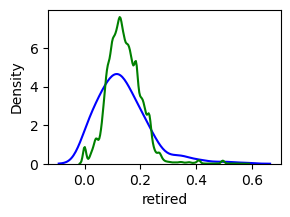

In [261]:
for b in buckets:
    plt.figure(figsize = (3, 2))
    sns.kdeplot(age3[b], color = 'blue')
    sns.kdeplot(parcels[f'{b}_score'], color = 'green')
    plt.show()

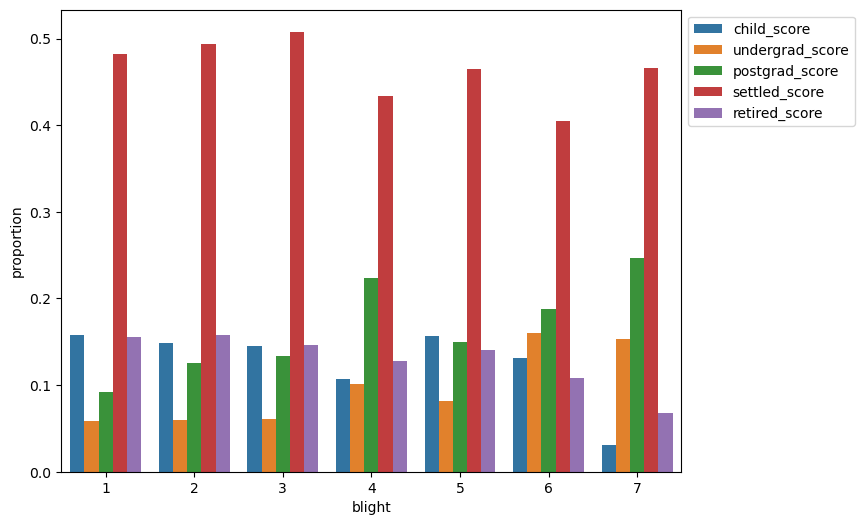

In [209]:
toPlot = parcels.groupby('blight')[[f'{b}_score' for b in buckets]].mean().reset_index().melt(id_vars = 'blight', var_name = 'bucket', value_name = 'proportion')

plt.figure(figsize = (8, 6))
sns.barplot(toPlot, x = 'blight', y = 'proportion', hue = 'bucket')
plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.show()

In [213]:
parcels.groupby('blight')[[f'{b}_score' for b in buckets]].mean().T

blight,1,2,3,4,5,6,7
child_score,0.16,0.15,0.15,0.11,0.16,0.13,0.03
undergrad_score,0.06,0.06,0.06,0.10,0.08,0.16,0.15
postgrad_score,0.09,0.13,0.13,0.22,0.15,0.19,0.25
settled_score,0.48,0.49,0.51,0.43,0.46,0.40,0.47
retired_score,0.16,0.16,0.15,0.13,0.14,0.11,0.07


In [262]:
model = smf.ols(formula = 'postgrad_score ~ C(blight)', data = parcels).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         postgrad_score   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     4745.
Date:                Sat, 10 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:29:22   Log-Likelihood:             1.5684e+05
No. Observations:              135928   AIC:                        -3.137e+05
Df Residuals:                  135921   BIC:                        -3.136e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0925      0.001    134.